In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import pathlib
from matplotlib.colors import LinearSegmentedColormap
import mapclassify as mc

salmon_cmap = LinearSegmentedColormap.from_list(
    "salmon_cmap",
    ["#fff5f0", "#fddbc7", "#f4a582", "#ef8a62", "#d6604d", "#b2182b"]
)

plt.rcParams["font.family"] = "Noto Sans KR"

BASE_PATH = pathlib.Path().resolve()

if BASE_PATH.name == "notebooks":
    BASE_PATH = BASE_PATH.parent
elif BASE_PATH.name != "analysis_table" and (BASE_PATH / "analysis_table").exists():
    BASE_PATH = BASE_PATH / "analysis_table"

INPUT_PATH = BASE_PATH / "data" / "input"
OUTPUT_PATH = BASE_PATH / "data" / "output"

DATA_PATH = INPUT_PATH
RAW_DATA = DATA_PATH / "raw"
PRO_DATA = OUTPUT_PATH

IMAGE_PATH = BASE_PATH / "image"
IMAGE_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
MAKING_TABLE_PATH = OUTPUT_PATH
WELFARE_PATH = DATA_PATH / "welfare"
WELFARE_PATH.mkdir(parents=True, exist_ok = True)



## 기초생활수급자 데이터 불러오기, 데이터 전처리
    # 결측치 1-2개, 0인 값으로 판단 -> 0으로처리

In [2]:
base = pd.read_csv(WELFARE_PATH / "국민기초생활보장_수급자_2023.csv",
                      encoding = 'utf-8')

print(f"기초생활 구조: {base.shape}")
print(f"기초생활 칼럼: {base.columns}")
display(base.head(10), base.tail(10))
print(base.info())

# 필요 행, 열 선택
base.head()
basic = base[["동별(1)", "동별(2)", "2023.2", "2023.3", "2023.4"]]
basic.rename(columns = {"동별(1)": "시군구",
                         "동별(2)": "행정동", 
                         "2023.2": "기초생활수급자수", 
                         "2023.3": "기초생활수급자수_남성", 
                         "2023.4": "기초생활수급자수_여성"}, 
              inplace = True,
              errors = 'ignore')
basic = basic.iloc[3:]
basic = basic[(basic["시군구"] != "합계") & (basic["시군구"] != "본청") & 
                (basic["행정동"] != "소계") & (basic["행정동"] != "기타")]

# 결측치 처리
basic[["기초생활수급자수", "기초생활수급자수_남성", "기초생활수급자수_여성"]] = \
    basic[["기초생활수급자수", "기초생활수급자수_남성", "기초생활수급자수_여성"]].replace("-", np.nan)
print(f"\n기초수급자 결측치 확인 \n{basic.isna().sum()}")
basic[["기초생활수급자수", "기초생활수급자수_남성", "기초생활수급자수_여성"]] = basic[["기초생활수급자수", "기초생활수급자수_남성", "기초생활수급자수_여성"]].replace(np.nan, 0).astype(int)
print(f"\n기초수급자 결측치 처리 확인: \n{basic.isna().sum()}")

# 남녀 합 확인
income_sex = basic.copy()
income_sex["남여합"] = basic["기초생활수급자수_남성"] + basic["기초생활수급자수_여성"]
income_sex["합차"] = basic["기초생활수급자수"] - income_sex["남여합"]
print("\n남성+여성과 총 기초수급자 수 비교")
display(income_sex["합차"].describe())

# 기본 정보 확인
print(f"\n기초수급자 구조 확인: {basic.shape}")
display(basic.info(), basic.describe(include='all'))
print(f"\n기초수급자 중복값 확인: {basic.duplicated().sum()}")
print(len(basic))



기초생활 구조: (481, 24)
기초생활 칼럼: Index(['동별(1)', '동별(2)', '2023', '2023.1', '2023.2', '2023.3', '2023.4',
       '2023.5', '2023.6', '2023.7', '2023.8', '2023.9', '2023.10', '2023.11',
       '2023.12', '2023.13', '2023.14', '2023.15', '2023.16', '2023.17',
       '2023.18', '2023.19', '2023.20', '2023.21'],
      dtype='str')


,동별(1),동별(2),2023,2023.1,2023.2,2023.3,2023.4,2023.5,2023.6,2023.7,...,2023.12,2023.13,2023.14,2023.15,2023.16,2023.17,2023.18,2023.19,2023.20,2023.21
0,동별(1),동별(2),총 수급자,총 수급자,총 수급자,총 수급자,총 수급자,일반수급자,일반수급자,일반수급자,...,조건부 수급자,특례수급자,특례수급자,특례수급자,특례수급자,시설수급자,시설수급자,시설수급자,시설수급자,시설수급자
1,동별(1),동별(2),가구 (가구),시설수 (개소),인원 (명),인원 (명),인원 (명),가구 (가구),인원 (명),인원 (명),...,인원 (명),가구 (가구),인원 (명),인원 (명),인원 (명),시설수 (개소),가구 (가구),인원 (명),인원 (명),인원 (명)
2,동별(1),동별(2),소계,소계,소계,남자,여자,소계,소계,남자,...,여자,소계,소계,남자,여자,소계,소계,소계,남자,여자
3,합계,소계,313313,599,428256,198122,230134,258561,332055,151165,...,40084,4776,5803,2654,3149,599,10321,10321,4310,6011
4,본청,소계,-,5,653,147,506,-,-,-,...,-,-,-,-,-,5,653,653,147,506
5,종로구,소계,4487,15,5799,3251,2548,3694,4274,2421,...,309,158,169,112,57,15,509,509,180,329
6,종로구,청운효자동,159,-,232,84,148,142,202,73,...,17,2,4,2,2,-,-,-,-,-
7,종로구,사직동,99,-,111,54,57,92,104,48,...,-,1,1,-,1,-,-,-,-,-
8,종로구,삼청동,36,-,44,22,22,26,30,14,...,4,3,4,2,2,-,-,-,-,-
9,종로구,부암동,111,-,130,59,71,97,108,48,...,7,5,5,1,4,-,-,-,-,-


,동별(1),동별(2),2023,2023.1,2023.2,2023.3,2023.4,2023.5,2023.6,2023.7,...,2023.12,2023.13,2023.14,2023.15,2023.16,2023.17,2023.18,2023.19,2023.20,2023.21
471,강동구,천호1동,1376,-,1773,830,943,1113,1379,641,...,183,35,42,20,22,-,-,-,-,-
472,강동구,천호2동,1619,-,2113,1032,1081,1326,1675,812,...,191,47,57,30,27,-,-,-,-,-
473,강동구,천호3동,1205,-,1466,744,722,981,1152,575,...,132,21,23,10,13,-,-,-,-,-
474,강동구,성내1동,269,-,388,193,195,212,281,138,...,52,2,2,2,-,-,-,-,-,-
475,강동구,성내2동,896,-,1066,534,532,730,864,428,...,86,15,15,5,10,-,-,-,-,-
476,강동구,성내3동,594,-,787,391,396,463,604,292,...,80,8,9,5,4,-,-,-,-,-
477,강동구,길동,1429,-,1833,911,922,1105,1366,665,...,210,18,19,8,11,-,-,-,-,-
478,강동구,둔촌1동,2,-,2,2,-,1,1,1,...,-,-,-,-,-,-,-,-,-,-
479,강동구,둔촌2동,447,-,592,271,321,367,464,212,...,63,6,7,1,6,-,-,-,-,-
480,강동구,기타,4,28,422,206,216,4,3,1,...,-,-,-,-,-,28,419,419,205,214


<class 'pandas.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 24 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   동별(1)    481 non-null    str  
 1   동별(2)    481 non-null    str  
 2   2023     481 non-null    str  
 3   2023.1   481 non-null    str  
 4   2023.2   481 non-null    str  
 5   2023.3   481 non-null    str  
 6   2023.4   481 non-null    str  
 7   2023.5   481 non-null    str  
 8   2023.6   481 non-null    str  
 9   2023.7   481 non-null    str  
 10  2023.8   481 non-null    str  
 11  2023.9   481 non-null    str  
 12  2023.10  481 non-null    str  
 13  2023.11  481 non-null    str  
 14  2023.12  481 non-null    str  
 15  2023.13  481 non-null    str  
 16  2023.14  481 non-null    str  
 17  2023.15  481 non-null    str  
 18  2023.16  481 non-null    str  
 19  2023.17  481 non-null    str  
 20  2023.18  481 non-null    str  
 21  2023.19  481 non-null    str  
 22  2023.20  481 non-null    str  
 23  2

count    426.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: 합차, dtype: float64


기초수급자 구조 확인: (426, 5)
<class 'pandas.DataFrame'>
Index: 426 entries, 6 to 479
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   시군구          426 non-null    str  
 1   행정동          426 non-null    str  
 2   기초생활수급자수     426 non-null    int64
 3   기초생활수급자수_남성  426 non-null    int64
 4   기초생활수급자수_여성  426 non-null    int64
dtypes: int64(3), str(2)
memory usage: 20.0 KB


None

,시군구,행정동,기초생활수급자수,기초생활수급자수_남성,기초생활수급자수_여성
count,426,426,426.000000,426.000000,426.000000
unique,25,425,NaN,NaN,NaN
top,송파구,신사동,NaN,NaN,NaN
freq,27,2,NaN,NaN,NaN
mean,NaN,NaN,980.265258,454.558685,525.706573
std,NaN,NaN,746.889615,340.867706,418.497779
min,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,436.500000,194.250000,222.500000
50%,NaN,NaN,808.000000,377.500000,414.000000
75%,NaN,NaN,1369.500000,634.000000,734.750000



기초수급자 중복값 확인: 0
426


## 차상위계층 데이터 불러오기 및 전처리
    # 행정동 개수 확인: 452
    # 행정동 확인 필요(서울시 행정동 426개와 다름)

 
    # 조사결과:
    행정동 구역 및 명칭 개편 
        # 강남구 일원2동 -> 개포3동
        # 강동구 상일동 -> 상일1동, 상일2동
        # 강동구 상일제1동 -> ?
        # 강동구 상일제2동 -> ?
        # 노원구 상계6동, 상계7동 -> 상계6.7동
        # 노원구 상계11동~상계23동 -> 현재 공식 행정동 아님
        # 상일동 -> 1, 2동으로 분리됨. 왜 상일제1동과 제2동이 있는지 의문/

    # 표기 방식 차이
                -> - , '제', 개포3동 없음, . -> 

    # 차상위 데이터 '제' 표기방식 패턴확인:
                1. 차상위 데이터에 “제” 표기만 있는 경우
                -> 기초생활수급자/격자 기준 행정동명과 맞추기 위해 “제” 제거 필요

                2. “제” 표기와 일반 표기가 동시에 있는 경우
                -> 일반 표기 쪽 인원이 대부분이고, “제” 표기 행은 매우 작음
                -> 원자료 내 일부 행정동명 표기 오류 또는 잔여 표기로 판단 가능

                3. 따라서 “제”를 제거해 현재 행정동명 기준으로 통일하고,
                같은 시군구+행정동으로 합산하는 방식이 실무적으로 가능
        

    # 상계11-23동
                노원구 상계11동~상계23동은 현재 공식 행정동명에 존재하지 않는 값으로 확인
                원자료상 상계10동 이후에 연속적으로 등장하는 비정상 행정동명으로 판단 (데이터 입력 오류로 밀려 들어갔을 가능성)    
                상계10동으로 보정하여 합산

    # 행정동 전처리 방식:
        # 기호 표기 수정 (모두 100m 격자 서울시 추정인구 테이블의 행정동 표기법과 맞춤)
        # 차상위
        


In [3]:

classed = pd.read_csv(WELFARE_PATH / "서울시_차상위계층_동별_연령별_현황_2023.csv",
                       encoding = 'cp949')
classed.head()
classed.tail()
display(classed)

# 필요 칼럼 선택
classed = classed[["시군구", "읍면동", "연령구간", "자격", "수급권자수"]]

# EDA
display(classed.head(10))
classed.info()
classed.describe()
    # 결측치 없음
    # 지역 간 수급권자수 편차가 큼

classed = classed.groupby(by = ["시군구", "읍면동", "연령구간"], as_index = False)["수급권자수"].sum()
classed = classed.rename(columns = {"읍면동": "행정동",
                                    "수급권자수": "차상위계층수급권자수"})

# 행정동 개수 확인
print(f"행정동 개수 확인: {classed[["시군구", "행정동"]].drop_duplicates().shape[0]}")
    # 행정동 개수 확인: 452
    # 행정동 확인 필요

,시도,시군구,읍면동,자격,연령구간,가구수,수급권자수
0,서울특별시,종로구,청운효자동,모자가족,18세미만,0,23
1,서울특별시,종로구,청운효자동,모자가족,18~64세,21,30
2,서울특별시,종로구,청운효자동,부자가족,18세미만,0,3
3,서울특별시,종로구,청운효자동,부자가족,18~64세,4,9
4,서울특별시,종로구,청운효자동,차상위장애인,18~64세,9,10
...,...,...,...,...,...,...,...
6389,서울특별시,강동구,둔촌2동,차상위본인부담경감대상자,18~64세,29,19
6390,서울특별시,강동구,둔촌2동,차상위본인부담경감대상자,65세이상,28,31
6391,서울특별시,강동구,둔촌2동,차상위계층 확인,18세미만,0,3
6392,서울특별시,강동구,둔촌2동,차상위계층 확인,18~64세,25,49


,시군구,읍면동,연령구간,자격,수급권자수
0,종로구,청운효자동,18세미만,모자가족,23
1,종로구,청운효자동,18~64세,모자가족,30
2,종로구,청운효자동,18세미만,부자가족,3
3,종로구,청운효자동,18~64세,부자가족,9
4,종로구,청운효자동,18~64세,차상위장애인,10
5,종로구,청운효자동,65세이상,차상위장애인,9
6,종로구,청운효자동,18~64세,차상위자활,1
7,종로구,청운효자동,18세미만,차상위본인부담경감대상자,9
8,종로구,청운효자동,18~64세,차상위본인부담경감대상자,9
9,종로구,청운효자동,65세이상,차상위본인부담경감대상자,26


<class 'pandas.DataFrame'>
RangeIndex: 6394 entries, 0 to 6393
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   시군구     6394 non-null   str  
 1   읍면동     6394 non-null   str  
 2   연령구간    6394 non-null   str  
 3   자격      6394 non-null   str  
 4   수급권자수   6394 non-null   int64
dtypes: int64(1), str(4)
memory usage: 249.9 KB
행정동 개수 확인: 452


## 기초, 차상위, GRID 행정동 전처리
    # 조사결과:
    행정동 구역 및 명칭 개편 
        # 강남구 일원2동 -> 개포3동
        # 강동구 상일동 -> 상일1동, 상일2동
        # 강동구 상일제1동 -> ?
        # 강동구 상일제2동 -> ?
        # 노원구 상계6동, 상계7동 -> 상계6.7동
        # 노원구 상계11동~상계23동 -> 현재 공식 행정동 아님
        # 상일동 -> 1, 2동으로 분리됨. 왜 상일제1동과 제2동이 있는지 의문/

    # 표기 방식 차이
                -> - , '제', 개포3동 없음, . -> 

    # 차상위 데이터 '제' 표기방식 패턴확인:
                1. 차상위 데이터에 “제” 표기만 있는 경우
                -> 기초생활수급자/격자 기준 행정동명과 맞추기 위해 “제” 제거 필요

                2. “제” 표기와 일반 표기가 동시에 있는 경우
                -> 일반 표기 쪽 인원이 대부분이고, “제” 표기 행은 매우 작음
                -> 원자료 내 일부 행정동명 표기 오류 또는 잔여 표기로 판단 가능

                3. 따라서 “제”를 제거해 현재 행정동명 기준으로 통일하고,
                같은 시군구+행정동으로 합산하는 방식이 실무적으로 가능
        

    # 상계11-23동
                노원구 상계11동~상계23동은 현재 공식 행정동명에 존재하지 않는 값으로 확인
                원자료상 상계10동 이후에 연속적으로 등장하는 비정상 행정동명으로 판단 (데이터 입력 오류로 밀려 들어갔을 가능성)    
                상계10동으로 보정하여 합산

    # 기초 - 격자 비교시 둘의 행정동 구역 및 명칭은 동일.
    # 다만, 기초는 .을 격자는 중간점을 사용


**행정동 전처리 방식 요약**
- 최종 결합 기준은 100m 격자 테이블의 `시군구 + 행정동`으로 설정함
- 기초생활수급자 데이터는 행정동 구역은 격자와 동일하나, `.` / `·` 표기 차이만 확인되어 격자 표기 기준으로 수정함
- 차상위계층 데이터는 행정동 개편, `제` 표기, 특수문자 표기, 비공식 행정동명이 혼재되어 있어 수동 매핑 방식으로 정리함
- 명칭 수정 후 같은 `시군구 + 행정동`으로 묶이는 행은 수급자 수를 합산함
- 이후 `시군구 + 행정동` 키 기준으로 격자, 기초생활수급자, 차상위계층 간 매칭 여부를 재점검함
- 최종 검토 결과, 격자 기준 행정동에 복지 데이터가 모두 결합되는지 확인함 




In [4]:
# 그리드 데이터 불러오기
grid = gpd.read_file(OUTPUT_PATH / "서울시_100m_추정인구.gpkg")
grid.head()

,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,추정_인구수,GRID_CD_500,geometry
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603..."


In [5]:
# 비교 키 생성
basic_key = basic[["시군구", "행정동"]].drop_duplicates()
classed_key = classed[["시군구", "행정동"]].drop_duplicates()
grid_key = grid[["시군구", "행정동"]].drop_duplicates()

# basic - classed 비교
basic_classed = basic_key.merge(classed_key,
                                on = ["시군구", "행정동"], 
                                how = 'left',
                                indicator = True)
classed_basic = classed_key.merge(basic_key,
                                  on = ["시군구", "행정동"],
                                  how = 'left',
                                  indicator = True)

print("차상위에 없지만 기초에 있음")
display(basic_classed[basic_classed["_merge"] == 'left_only'])


print("기초에 없지만 차상위에 있음")
display(classed_basic[classed_basic["_merge"] == 'left_only'])

classed[(classed["행정동"] == '상일동') | (classed["행정동"] == '상일제1동') | (classed["행정동"] == '상일제2동')]
classed[(classed["행정동"] == '번1동') | (classed["행정동"] == '번제1동') | (classed["행정동"] == '번2동') | (classed["행정동"] == '번제2동')]
classed[(classed["행정동"] == '상계11동') | (classed["행정동"] == '상계1동')]
classed[(classed["행정동"] == '수유1동') | (classed["행정동"] == '수유제1동') | (classed["행정동"] == '수유2동') | (classed["행정동"] == '수유제2동')]
classed[classed["행정동"] == "길음제2동"]
    # 패턴 발견: 제만 있을 때는 인구 보존, 제와 제 없는 버전 함께 있을 때 제 없는 버전의 인구가 매우 적음


# grid - basic, grid - classed비교
print("기초에 없지만 격자에 있음")
grid_basic = grid_key.merge(basic_key, 
                            on = ["시군구", "행정동"],
                            how = 'left',
                            indicator = True)
display(grid_basic[grid_basic["_merge"] == 'left_only'])

print("격자에 없지만 기초에 있음")
basic_grid = basic_key.merge(grid_key, 
                            on = ["시군구", "행정동"],
                            how = 'left',
                            indicator = True)
display(basic_grid[basic_grid["_merge"] == 'left_only'])

print("="*100)

print("차상위에 없지만 격자에 있음")
grid_classed = grid_key.merge(classed,
                          on = ["시군구", "행정동"],
                          how = 'left',
                          indicator = True)
display(grid_classed[grid_classed["_merge"] == 'left_only'])

print("격자에 없지만 차상위에 있음")
classed_grid = classed.merge(grid_key,
                          on = ["시군구", "행정동"],
                          how = 'left',
                          indicator = True)
display(classed_grid[classed_grid["_merge"] == 'left_only'])

차상위에 없지만 기초에 있음


,시군구,행정동,_merge
56,성동구,금호2.3가동,left_only
76,광진구,자양4동,left_only
99,중랑구,면목3.8동,left_only
122,성북구,길음2동,left_only
167,노원구,중계2.3동,left_only
374,강남구,개포3동,left_only
408,강동구,상일1동,left_only
409,강동구,상일2동,left_only


기초에 없지만 차상위에 있음


,시군구,행정동,_merge
0,강남구,강남구,left_only
20,강남구,일원2동,left_only
23,강동구,강동구,left_only
32,강동구,상일동,left_only
33,강동구,상일제1동,left_only
34,강동구,상일제2동,left_only
44,강북구,강북구,left_only
49,강북구,번제1동,left_only
50,강북구,번제2동,left_only
51,강북구,번제3동,left_only


기초에 없지만 격자에 있음


...

,시군구,행정동,_merge
8,종로구,종로1.2.3.4가동,left_only
9,종로구,종로5.6가동,left_only
56,성동구,금호2.3가동,left_only
99,중랑구,면목3.8동,left_only
167,노원구,중계2.3동,left_only
170,노원구,상계3.4동,left_only
172,노원구,상계6.7동,left_only


차상위에 없지만 격자에 있음


,시군구,행정동,연령구간,차상위계층수급권자수,_merge
204,강남구,개포3동,NaN,NaN,left_only
504,광진구,자양4동,NaN,NaN,left_only
667,강동구,상일1동,NaN,NaN,left_only
674,강동구,상일2동,NaN,NaN,left_only
708,성동구,금호2·3가동,NaN,NaN,left_only
871,종로구,종로1·2·3·4가동,NaN,NaN,left_only
875,종로구,종로5·6가동,NaN,NaN,left_only
954,중랑구,면목3·8동,NaN,NaN,left_only
1081,성북구,길음2동,NaN,NaN,left_only
1181,노원구,중계2·3동,NaN,NaN,left_only


격자에 없지만 차상위에 있음


,시군구,행정동,연령구간,차상위계층수급권자수,_merge
0,강남구,강남구,18~64세,1,left_only
58,강남구,일원2동,18~64세,78,left_only
59,강남구,일원2동,18세미만,24,left_only
60,강남구,일원2동,65세이상,191,left_only
67,강동구,강동구,18세미만,1,left_only
...,...,...,...,...,...
1198,종로구,종로5.6가동,18세미만,29,left_only
1199,종로구,종로5.6가동,65세이상,51,left_only
1284,중랑구,면목제3.8동,18~64세,437,left_only
1285,중랑구,면목제3.8동,18세미만,212,left_only


In [6]:
# 기초, 차상위 행정동 수정

# 기초생활수급자 행정동명 수정
basic_replace_dict = {
    "종로1.2.3.4가동": "종로1·2·3·4가동",
    "종로5.6가동": "종로5·6가동",
    "금호2.3가동": "금호2·3가동",
    "면목3.8동": "면목3·8동",
    "중계2.3동": "중계2·3동",
    "상계3.4동": "상계3·4동",
    "상계6.7동": "상계6·7동",
}

basic["행정동"] = basic["행정동"].replace(basic_replace_dict)

# 기초생활수급자 행정동명 표기 수정


# 차상위계층 행정동명 수정
classed_replace_dict = {
    # 구 단위 또는 원자료 이상 행은 제거 전 별도 처리 대상
    "강남구": np.nan,
    "강동구": np.nan,
    "강북구": np.nan,
    "구로구": np.nan,
    "성동구": np.nan,

    # 행정동 개편 및 표기 차이
    "일원2동": "개포3동",
    "상일동": "상일1동",
    "상일제1동": "상일1동",
    "상일제2동": "상일2동",

    # '제' 표기 차이
    "번제1동": "번1동",
    "번제2동": "번2동",
    "번제3동": "번3동",
    "수유제1동": "수유1동",
    "수유제2동": "수유2동",
    "자양제4동": "자양4동",
    "길음제2동": "길음2동",

    # 기호 표기 차이
    "금호2-3가동": "금호2·3가동",
    "면목제3.8동": "면목3·8동",
    "중계2,3동": "중계2·3동",
    "종로1.2.3.4가동": "종로1·2·3·4가동",
    "종로5.6가동": "종로5·6가동",

    # 노원구 현재 행정동 기준
    "상계3.4동": "상계3·4동",
    "상계6동": "상계6·7동",
    "상계7동": "상계6·7동",
    "상계6.7동": "상계6·7동",

    # 원자료 비공식 행정동명
    "상계11동": "상계10동",
    "상계12동": "상계10동",
    "상계13동": "상계10동",
    "상계14동": "상계10동",
    "상계15동": "상계10동",
    "상계16동": "상계10동",
    "상계17동": "상계10동",
    "상계18동": "상계10동",
    "상계19동": "상계10동",
    "상계20동": "상계10동",
    "상계21동": "상계10동",
    "상계22동": "상계10동",
    "상계23동": "상계10동",
}

classed["행정동"] = classed["행정동"].replace(classed_replace_dict)

# 구 단위 행 제거
classed = classed[classed["행정동"].notna()].copy()


# 행정동 표기 재검정
basic_key = basic[["시군구", "행정동"]].drop_duplicates()
classed_key = classed[["시군구", "행정동"]].drop_duplicates()
grid_key = grid[["시군구", "행정동"]].drop_duplicates()

# grid - basic, grid - classed비교
print("기초에 없지만 격자에 있음")
grid_basic = grid_key.merge(basic_key, 
                            on = ["시군구", "행정동"],
                            how = 'left',
                            indicator = True)
display(grid_basic[grid_basic["_merge"] == 'left_only'])

print("격자에 없지만 기초에 있음")
basic_grid = basic_key.merge(grid_key, 
                            on = ["시군구", "행정동"],
                            how = 'left',
                            indicator = True)
display(basic_grid[basic_grid["_merge"] == 'left_only'])

print("="*100)

print("차상위에 없지만 격자에 있음")
grid_classed = grid_key.merge(classed,
                          on = ["시군구", "행정동"],
                          how = 'left',
                          indicator = True)
display(grid_classed[grid_classed["_merge"] == 'left_only'])

print("격자에 없지만 차상위에 있음")
classed_grid = classed.merge(grid_key,
                          on = ["시군구", "행정동"],
                          how = 'left',
                          indicator = True)
display(classed_grid[classed_grid["_merge"] == 'left_only'])

# 성공!

기초에 없지만 격자에 있음


,시군구,행정동,_merge


격자에 없지만 기초에 있음


,시군구,행정동,_merge


차상위에 없지만 격자에 있음


,시군구,행정동,연령구간,차상위계층수급권자수,_merge


격자에 없지만 차상위에 있음


,시군구,행정동,연령구간,차상위계층수급권자수,_merge


## 테이블 생성

In [7]:
basic_clean = basic.groupby(by=["시군구", "행정동"], as_index=False)["기초생활수급자수"].sum()

classed_clean = classed.groupby(by = ["시군구", "행정동"], as_index=False)["차상위계층수급권자수"].sum()
classed_clean

# 테이블 생성
basic_clean.to_csv(OUTPUT_PATH / "서울시_기초생활수급자_행정동별_2023(가공).csv",
                   encoding = 'utf-8-sig',
                   index = False)
classed_clean.to_csv(OUTPUT_PATH / "서울시_차상위계층_행정동별_2021_2023(가공).csv",
                     encoding = 'utf-8-sig',
                     index = False)

## 데이터 불러오기

In [8]:
basic = pd.read_csv(OUTPUT_PATH / "서울시_기초생활수급자_행정동별_2023(가공).csv",
                    encoding = 'utf-8-sig')
classed = pd.read_csv(OUTPUT_PATH / "서울시_차상위계층_행정동별_2021_2023(가공).csv", 
                      encoding = 'utf-8-sig')

# 기초 eda
print("기초생활수급자 EDA")
print(f"결측치 확인: \n{basic.isna().sum()}")
print(f"행정동 중복값 확인: {basic[["시군구", "행정동"]].duplicated().sum()}")
display(basic.head())
print("="*100)

print("차상위계층 EDA")
print(f"결측치 확인: \n{classed.isna().sum()}")
print(f"행정동 중복값 확인: {classed[["시군구", "행정동"]].duplicated().sum()}")
display(classed.head())
print("="*100)

print("100m 그리드 EDA")
print(f"crs확인 : {grid.crs}")
print(f"결측치 확인: \n{grid.isna().sum()}")
print(f"그리도코드 중복값 확인: {grid["GRID_CD"].duplicated().sum()}")
display(grid.head())
print("="*100)

기초생활수급자 EDA
결측치 확인: 
시군구         0
행정동         0
기초생활수급자수    0
dtype: int64
행정동 중복값 확인: 0


,시군구,행정동,기초생활수급자수
0,강남구,개포1동,133
1,강남구,개포2동,226
2,강남구,개포3동,1368
3,강남구,개포4동,740
4,강남구,논현1동,906


차상위계층 EDA
결측치 확인: 
시군구           0
행정동           0
차상위계층수급권자수    0
dtype: int64
행정동 중복값 확인: 0


,시군구,행정동,차상위계층수급권자수
0,강남구,개포1동,74
1,강남구,개포2동,65
2,강남구,개포3동,293
3,강남구,개포4동,182
4,강남구,논현1동,172


100m 그리드 EDA
crs확인 : EPSG:5179
결측치 확인: 
GRID_CD        0
행정동코드          0
시군구            0
행정동            0
중심점_x          0
중심점_y          0
원본_인구수         0
주거면적           0
주택수            0
추정_인구수         0
GRID_CD_500    0
geometry       0
dtype: int64
그리도코드 중복값 확인: 0


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,추정_인구수,GRID_CD_500,geometry
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603..."


데이터 결합 구조 확인: (426, 4)
결합 성공 결측으로 확인: 시군구           0
행정동           0
기초생활수급자수      0
차상위계층수급권자수    0
dtype: int64


count     426.000000
mean     1367.485915
std      1003.511796
min         4.000000
25%       619.250000
50%      1113.000000
75%      1955.750000
max      6534.000000
Name: 문화누리대상자, dtype: float64

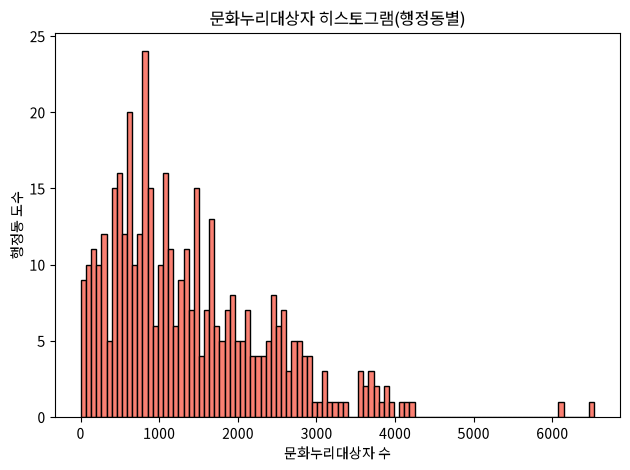

격자 데이터 결합 구조 확인: (60528, 15)
격자 결합 성공 결측으로 확인: GRID_CD        0
행정동코드          0
시군구            0
행정동            0
중심점_x          0
중심점_y          0
원본_인구수         0
주거면적           0
주택수            0
추정_인구수         0
GRID_CD_500    0
geometry       0
기초생활수급자수       0
차상위계층수급권자수     0
문화누리대상자        0
dtype: int64


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,추정_인구수,GRID_CD_500,geometry,기초생활수급자수,차상위계층수급권자수,문화누리대상자
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604...",795,331,1126
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605...",795,331,1126
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606...",795,331,1126
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616...",851,326,1177
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603...",795,331,1126
5,다사603368,11220670,서초구,양재2동,960350.0,1936850.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960300 1936800, 960300 1936900, 9604...",795,331,1126
6,다사604368,11220670,서초구,양재2동,960450.0,1936850.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960400 1936800, 960400 1936900, 9605...",795,331,1126
7,다사605368,11220670,서초구,양재2동,960550.0,1936850.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960500 1936800, 960500 1936900, 9606...",795,331,1126
8,다사606368,11220670,서초구,양재2동,960650.0,1936850.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960600 1936800, 960600 1936900, 9607...",795,331,1126
9,다사607368,11220670,서초구,양재2동,960750.0,1936850.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960700 1936800, 960700 1936900, 9608...",795,331,1126


In [9]:
# 차상위 + 기초생활수급자
        # 평균 1367, 중앙값 1113으로 행정동별로 비교적 좌측에서 고르게 분포
        # 최대 6534로 특정 지역에 몰려있는 경우 있음
        # 시각화 결과 오른쪽으로 꼬리가 긴 분포
        
        # 데이터 결합 구조 확인: (426, 4)
        # 결합 성공 결측으로 확인: 시군구           0
        # 행정동           0
        # 기초생활수급자수      0
        # 차상위계층수급권자수    0
        # dtype: int64
        # count     426.000000
        # mean     1367.485915
        # std      1003.511796
        # min         4.000000
        # 25%       619.250000
        # 50%      1113.000000
        # 75%      1955.750000
        # max      6534.000000
        # Name: 문화누리대상자, dtype: float64
basic_classed = basic.merge(classed, 
                            on = ["시군구", "행정동"],
                            how = "left")
print(f"데이터 결합 구조 확인: {basic_classed.shape}")
print(f"결합 성공 결측으로 확인: {basic_classed.isna().sum()}")
basic_classed.head()

basic_classed["문화누리대상자"] = basic_classed["기초생활수급자수"] + basic_classed["차상위계층수급권자수"]
display(basic_classed["문화누리대상자"].describe())
    # 평균 1367, 중앙값 1113으로 행정동별로 비교적 좌측에서 고르게 분포
    # 최대 6534로 특정 지역에 몰려있는 경우 있음
    # 시각화 결과 오른쪽으로 꼬리가 긴 분포
plt.hist(basic_classed["문화누리대상자"],
         bins = 100,
         color = 'salmon',
         edgecolor = 'black')
plt.title("문화누리대상자 히스토그램(행정동별)")
plt.xlabel("문화누리대상자 수")
plt.ylabel("행정동 도수")
plt.tight_layout()
plt.savefig(IMAGE_PATH / "문화누리대상자_기초생활_차상위_추정_분포도.png",
            bbox_inches = 'tight',
            pad_inches = 0.1,
            dpi = 240)
plt.show()


# 문화누리대상자 + 격자테이블 결합
        # 격자 데이터 결합 구조 확인: (60528, 15)
        # 격자 결합 성공 결측으로 확인: GRID_CD        0
        # 행정동코드          0
        # 시군구            0
        # 행정동            0
        # 중심점_x          0
        # 중심점_y          0
        # 원본_인구수         0
        # 주거면적           0
        # 주택수            0
        # 추정_인구수         0
        # GRID_CD_500    0
        # geometry       0
        # 기초생활수급자수       0
        # 차상위계층수급권자수     0
        # 문화누리대상자        0
        # dtype: int64
grid_mnc_pop = grid.merge(basic_classed, 
                          on = ["시군구", "행정동"],
                          how = 'left')
print(f"격자 데이터 결합 구조 확인: {grid_mnc_pop.shape}")
print(f"격자 결합 성공 결측으로 확인: {grid_mnc_pop.isna().sum()}")
display(grid_mnc_pop.head(10))

## 추가 데이터 불러오기

In [10]:
LAND_PATH = INPUT_PATH / "grid" / "공시지가"
HOME_PATH = INPUT_PATH / "grid" / "주택가격"

# 공시지가
land_list = list(LAND_PATH.glob("*/vl_blk.shp"))
df_list = []
for land in land_list:
    result = gpd.read_file(land,
                           encoding = 'utf-8-sig')
    result["시군구"] = land.parent.name.strip()
    df_list.append(result)

land = gpd.GeoDataFrame(pd.concat(df_list, 
                        ignore_index=True),
                        
                        crs = df_list[0].crs,
                        geometry = "geometry")

# 주택가격
home_list = list(HOME_PATH.glob("*/vl_blk.shp"))
df_list2 = []

for home in home_list:
    result = gpd.read_file(home,
                           encoding = 'utf-8-sig')
    result["시군구"] = home.parent.name.strip()
    df_list2.append(result)
    
home = gpd.GeoDataFrame(pd.concat(df_list2, ignore_index=True), 
                        crs = df_list2[0].crs,
                        geometry = "geometry")

# 칼럼 선택
land = land[["gid", "val", "geometry"]]
land = land.rename(columns = {"gid": "GRID_CD",
                    "val": "공시지가"})

home = home[["gid", "val", "geometry"]]
home = home.rename(columns = {"gid": "GRID_CD",
                    "val": "주택가격"})

# eda
print("공시지가 그리드 EDA")
print(f"데이터 구조확인 : {land.shape}")
print(f"crs확인 : {land.crs}")
print(f"geomtype확인 : {land.geometry.geom_type.unique()}")
print(f"결측치 확인: \n{land.isna().sum()}")
print(f"그리드코드 중복확인: {land[["GRID_CD"]].duplicated().sum()}")
display(land.head())
print("="*100)

print("주택가격 그리드 EDA")
print(f"데이터 구조확인 : {home.shape}")
print(f"crs확인 : {home.crs}")
print(f"geomtype확인 : {home.geometry.geom_type.unique()}")
print(f"결측치 확인: \n{home.isna().sum()}")
print(f"그리드코드 중복확인: {home["GRID_CD"].duplicated().sum()}")
display(home.head())
print("="*100)

공시지가 그리드 EDA
데이터 구조확인 : (64681, 3)
crs확인 : EPSG:5179
geomtype확인 : <StringArray>
['Polygon']
Length: 1, dtype: str
결측치 확인: 
GRID_CD         0
공시지가        19500
geometry        0
dtype: int64
그리드코드 중복확인: 3029


,GRID_CD,공시지가,geometry
0,다사565474,NaN,"POLYGON ((956500 1947400, 956500 1947500, 9566..."
1,다사565475,NaN,"POLYGON ((956500 1947500, 956500 1947600, 9566..."
2,다사566473,NaN,"POLYGON ((956600 1947300, 956600 1947400, 9567..."
3,다사566474,330000.0,"POLYGON ((956600 1947400, 956600 1947500, 9567..."
4,다사566475,NaN,"POLYGON ((956600 1947500, 956600 1947600, 9567..."


주택가격 그리드 EDA
데이터 구조확인 : (64681, 3)
crs확인 : EPSG:5179
geomtype확인 : <StringArray>
['Polygon']
Length: 1, dtype: str
결측치 확인: 
GRID_CD         0
주택가격        44283
geometry        0
dtype: int64
그리드코드 중복확인: 3029


,GRID_CD,주택가격,geometry
0,다사565474,NaN,"POLYGON ((956500 1947400, 956500 1947500, 9566..."
1,다사565475,NaN,"POLYGON ((956500 1947500, 956500 1947600, 9566..."
2,다사566473,NaN,"POLYGON ((956600 1947300, 956600 1947400, 9567..."
3,다사566474,NaN,"POLYGON ((956600 1947400, 956600 1947500, 9567..."
4,다사566475,NaN,"POLYGON ((956600 1947500, 956600 1947600, 9567..."


## 공시지가, 주택가격 데이터 전처리
    # 결측치처리
        # 가격 결측치 = 0인 경우가 소수 이므로 일괄 0처리 하지 않음
        # 주택 혹은 거래 가능 토지가 없거나 데이터 제공되지 않는 지역일 가능성

    # 중복값 정리
        # GRID_CD 별 그룹화
        # 공시지가, 주택가격이므로 평균 처리
        # 중복값 확인: (np.int64(0), np.int64(0))
        # 결측값 확인 
        # GRID_CD         0
        # 공시지가        17395
        # geometry        0
        # dtype: int64, 
        # GRID_CD         0
        # 주택가격        41390
        # geometry        0
        # dtype: int64

In [11]:
# 결측치처리
    # 그룹시 평균을 계산을 위해 일시적으로 남겨둠
    # 이후 전처리 예정
# 중복값 정리
    # GRID_CD 별 그룹화
    # 공시지가, 주택가격이므로 평균 처리
    
    # 중복값 확인: (np.int64(0), np.int64(0))
    # 결측값 확인 
    # GRID_CD         0
    # 공시지가        17395
    # geometry        0
    # dtype: int64, 
    # GRID_CD         0
    # 주택가격        41390
    # geometry        0
    # dtype: int64
    
    
land[land["GRID_CD"].duplicated(keep = False)].sort_values("GRID_CD").head(30)

land_clean = land.groupby(by = "GRID_CD", as_index=False).agg({"공시지가": 'mean',
                                                                "geometry": 'first'})

home_clean = home.groupby(by = "GRID_CD", as_index=False).agg({"주택가격": 'mean',
                                                                "geometry": 'first'})

print(f"중복값 확인: {land_clean["GRID_CD"].duplicated().sum(), home_clean["GRID_CD"].duplicated().sum()}")
print(f"결측값 확인 \n{land_clean.isna().sum()}, \n{home_clean.isna().sum()}")


print(f"공시지가 0 레코드 확인: {(land_clean["공시지가"]==0).sum()}")
print(f"주택가격 0 레코드 확인: {(home_clean["주택가격"]==0).sum()}")

중복값 확인: (np.int64(0), np.int64(0))
결측값 확인 
GRID_CD         0
공시지가        17395
geometry        0
dtype: int64, 
GRID_CD         0
주택가격        41390
geometry        0
dtype: int64
공시지가 0 레코드 확인: 0
주택가격 0 레코드 확인: 0


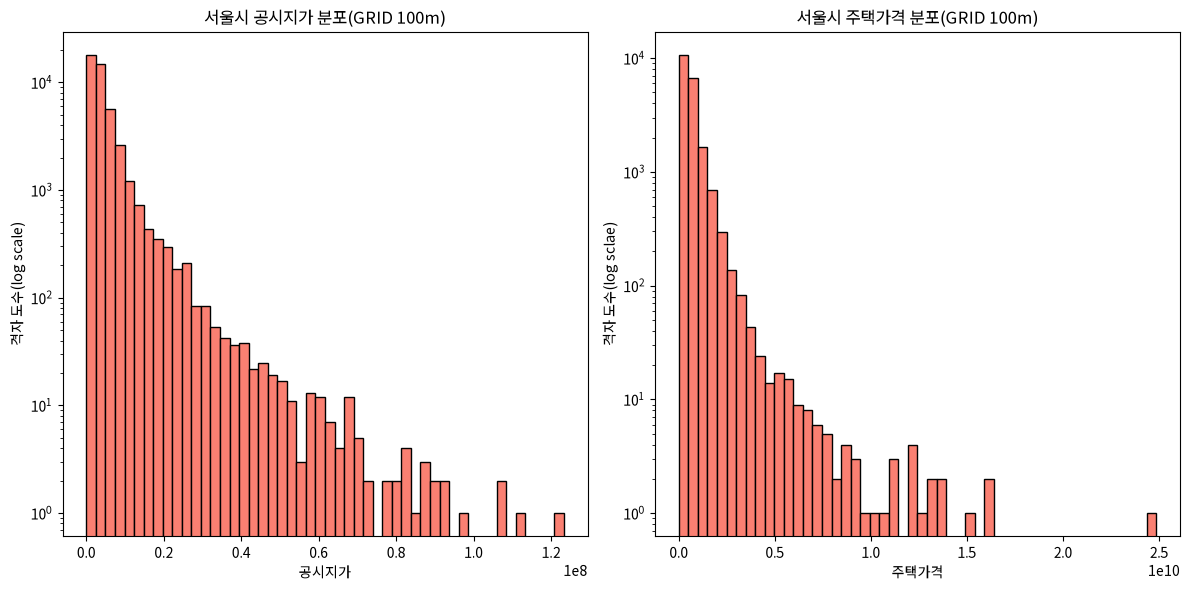

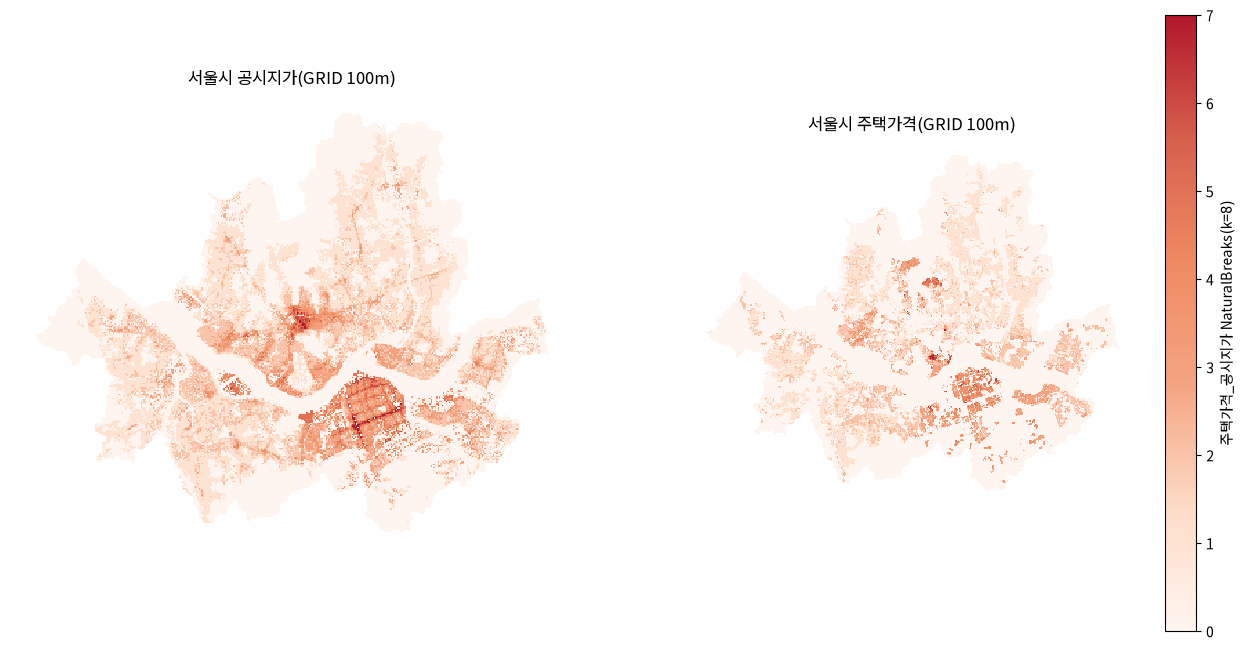

In [12]:
# eda 시각자료
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].hist(land["공시지가"], 
         color = 'salmon',
         edgecolor = 'black',
         bins = 50)
ax[0].set_title("서울시 공시지가 분포(GRID 100m)", fontsize=12)
ax[0].set_xlabel("공시지가")
ax[0].set_ylabel("격자 도수(log scale)")
ax[0].set_yscale('log')

ax[1].hist(home["주택가격"], 
         color = 'salmon',
         edgecolor = 'black',
         bins = 50)
ax[1].set_title("서울시 주택가격 분포(GRID 100m)", fontsize=12)
ax[1].set_xlabel("주택가격")
ax[1].set_ylabel("격자 도수(log sclae)")
ax[1].set_yscale('log')
plt.tight_layout()
plt.savefig(IMAGE_PATH / "서울시_공시지가_주택가격_분포도.png",
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi = 240)
plt.show()


land_plot = land.copy()
land_plot["공시지가_nb"] = mc.NaturalBreaks(land_plot["공시지가"].fillna(0), k=8).yb
home_plot = home.copy()
home_plot["주택가격_nb"] = mc.NaturalBreaks(home_plot["주택가격"].fillna(0), k=8).yb

fig, ax = plt.subplots(1, 2, figsize = (16, 8))
land_plot.plot(ax = ax[0],
               column = "공시지가_nb",
               cmap = salmon_cmap,
               edgecolor = None)
home_plot.plot(ax = ax[1],
               column = "주택가격_nb",
               cmap = salmon_cmap,
               legend = True,
               legend_kwds = {"label": "주택가격_공시지가 NaturalBreaks(k=8)"},
               edgecolor = None)
ax[0].set_title("서울시 공시지가(GRID 100m)")
ax[1].set_title("서울시 주택가격(GRID 100m)")
ax[0].set_axis_off()
ax[1].set_axis_off()
plt.savefig(IMAGE_PATH / "서울시_공시지가_주택가격_분포지도.png",
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi = 240)
plt.show()

## 격자 테이블 + 공시지가 + 주택가격 결합

In [13]:
# 격자 + 공시지가 + 주택 결합
grid_mnc = grid_mnc_pop.merge(land_clean[["GRID_CD", "공시지가"]],
                              on = "GRID_CD", 
                              how = 'left',
                              validate = "one_to_one")

grid_mnc = grid_mnc.merge(home_clean[["GRID_CD", "주택가격"]],
                          on = "GRID_CD",
                          how = 'left',
                          validate = "one_to_one")

grid_mnc.head()

,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,추정_인구수,GRID_CD_500,geometry,기초생활수급자수,차상위계층수급권자수,문화누리대상자,공시지가,주택가격
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604...",795,331,1126,21500.00,NaN
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605...",795,331,1126,NaN,NaN
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606...",795,331,1126,NaN,NaN
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616...",851,326,1177,NaN,NaN
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603...",795,331,1126,21699.99,NaN


## 공시지가, 주택가격 결측치 처리
    # 결측 여부 별 변수 분포 확인
        # 결측 집단에서는 상대적으로 주택수, 주거면적, 추정인구수가 낮게 나타남
        # 공시지가는 결측이 비교적 특정 지역에서만 나타나는데 반해 주택가격은 많은 수가 광범위하게 나타남
        # 주택가격은 보정 사용하더라도 리스크가 크다고 판단, 공시지가만 500m 격자 평균값(중앙값) 그리고 행정동별 격자 평균값(중앙값) 보정 후 사용 결정

    # 결측치 처리 방법
        # 500격자 그룹 후 평균 혹은 중앙값으로 전처리
        # 500m 격자의 평균 전처리 후 공시지가 결측값:2022
        # 행정동별 평균 전처리 후 공시지가 결측값:0

공시지가_결측                       0             1
추정_인구수     count   43994.000000  16534.000000
           mean      187.470405     65.869844
           std       236.934203    224.365778
           median     88.000000      0.000000
주택수        count   43994.000000  16534.000000
           mean       61.273719     23.256502
           std        83.644829     72.144564
           median     22.000000      0.000000
주거면적       count   43994.000000  16534.000000
           mean       95.058435      0.114499
           std       123.564093      5.463873
           median      0.000000      0.000000
기초생활수급자수   count   43994.000000  16534.000000
           mean     1084.825613   1078.991775
           std       787.641375    830.941442
           median    898.000000    934.000000
차상위계층수급권자수 count   43994.000000  16534.000000
           mean      432.818248    439.549534
           std       307.638275    341.360851
           median    353.000000    331.000000
문화누리대상자    count   43994.000000  16534.000000
           mean     1517.643861   1518.541309
           std      1071.021007   1145.634933
           median   1282.000000   1385.000000

주택가격_결측                       0             1
추정_인구수     count   20252.000000  40276.000000
           mean      265.767035     98.181324
           std       194.130206    240.936579
           median    250.000000      0.000000
주택수        count   20252.000000  40276.000000
           mean       83.801945     34.339110
           std        71.385490     82.639446
           median     71.000000      0.000000
주거면적       count   20252.000000  40276.000000
           mean      206.591640      0.000000
           std       100.701113      0.000000
           median    191.350000      0.000000
기초생활수급자수   count   20252.000000  40276.000000
           mean     1098.711535   1075.448456
           std       680.704513    853.188522
           median    986.000000    851.000000
차상위계층수급권자수 count   20252.000000  40276.000000
           mean      441.420107    431.256282
           std       283.411918    332.872865
           median    373.000000    331.000000
문화누리대상자    count   20252.000000  40276.000000
           mean     1540.131641   1506.704737
           std       945.811037   1158.266904
           median   1358.000000   1177.000000

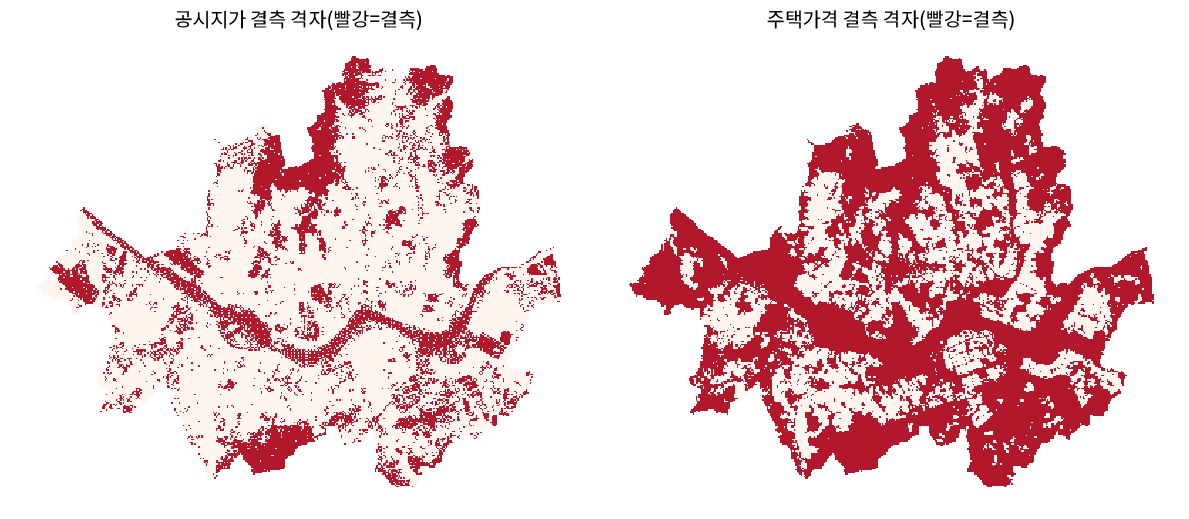

In [14]:
grid_mnc_na = grid_mnc.copy()

na_cols = ["추정_인구수", "주택수", "주거면적", "기초생활수급자수", "차상위계층수급권자수", "문화누리대상자"]

# 결측 여부 별 변수 분포 확인
    # 결측 집단에서는 상대적으로 주택수, 주거면적, 추정인구수가 낮게 나타남
    # 공시지가는 결측이 비교적 특정 지역에서만 나타나는데 반해 주택가격은 많은 수가 광범위하게 나타남
    # 주택가격은 보정 사용하더라도 리스크가 크다고 판단, 공시지가만 500m 격자 평균값(중앙값) 그리고 행정동별 격자 평균값(중앙값) 보정 후 사용 결정
grid_mnc_na["공시지가_결측"] = grid_mnc_na["공시지가"].isna().astype(int)
grid_mnc_na["주택가격_결측"] = grid_mnc_na["주택가격"].isna().astype(int)


land_na = grid_mnc_na.groupby("공시지가_결측")[na_cols].agg(["count", 'mean', 'std', 'median'])
home_na = grid_mnc_na.groupby("주택가격_결측")[na_cols].agg(["count", 'mean', 'std', 'median'])

display(land_na.T)
display(home_na.T)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))

grid_mnc_na.plot(
    ax=ax[0],
    column="공시지가_결측",
    cmap=salmon_cmap,
    linewidth=0
)

grid_mnc_na.plot(
    ax=ax[1],
    column="주택가격_결측",
    cmap=salmon_cmap,
    linewidth=0
)
    
ax[0].set_title("공시지가 결측 격자(빨강=결측)", fontsize=14)
ax[1].set_title("주택가격 결측 격자(빨강=결측)", fontsize=14)

ax[0].set_axis_off()
ax[1].set_axis_off()

plt.tight_layout()
plt.savefig(IMAGE_PATH / "공시지가_주태가격_결측비교_지도.png",
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi=240)
plt.show()


500m 격자의 평균 전처리 후 공시지가 결측값:2022
행정동별 평균 전처리 후 공시지가 결측값:0


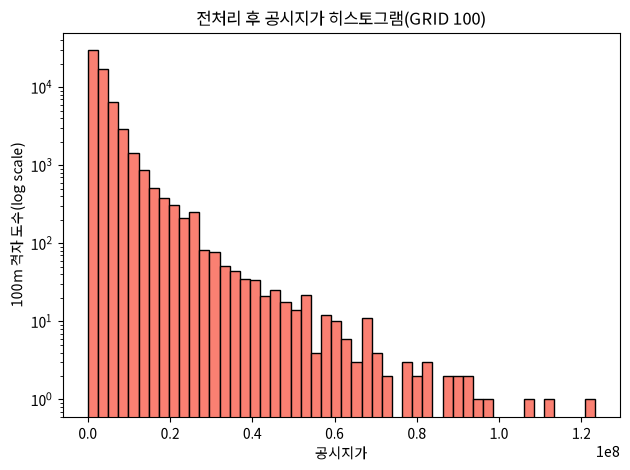

In [15]:
#결측치처리

# 500격자 그룹 후 평균 혹은 중앙값으로 전처리
    # 500m 격자의 평균 전처리 후 공시지가 결측값:2022
    # 행정동별 평균 전처리 후 공시지가 결측값:0
land_na_mean = grid_mnc.groupby("GRID_CD_500")["공시지가"].transform('mean')
grid_mnc["공시지가"] = grid_mnc["공시지가"].fillna(land_na_mean)
print(f"500m 격자의 평균 전처리 후 공시지가 결측값:{grid_mnc["공시지가"].isna().sum()}")

land_na_hjd = grid_mnc.groupby(["시군구", "행정동"])["공시지가"].transform('mean')
grid_mnc["공시지가"] = grid_mnc["공시지가"].fillna(land_na_hjd)
print(f"행정동별 평균 전처리 후 공시지가 결측값:{grid_mnc["공시지가"].isna().sum()}")


plt.hist(grid_mnc["공시지가"],
         color = 'salmon',
         edgecolor = 'black',
         bins = 50)
plt.title("전처리 후 공시지가 히스토그램(GRID 100)")
plt.xlabel('공시지가')
plt.ylabel('100m 격자 도수(log scale)')
plt.savefig(IMAGE_PATH / "공시지가_전처리_히스토그램.png",
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi=240)
plt.yscale('log')
plt.tight_layout()
plt.show()



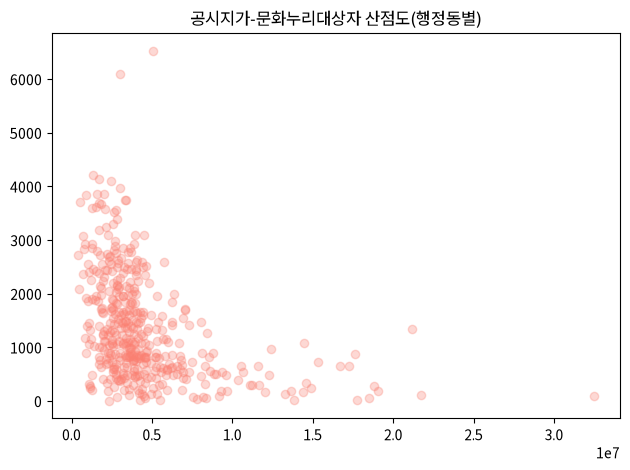

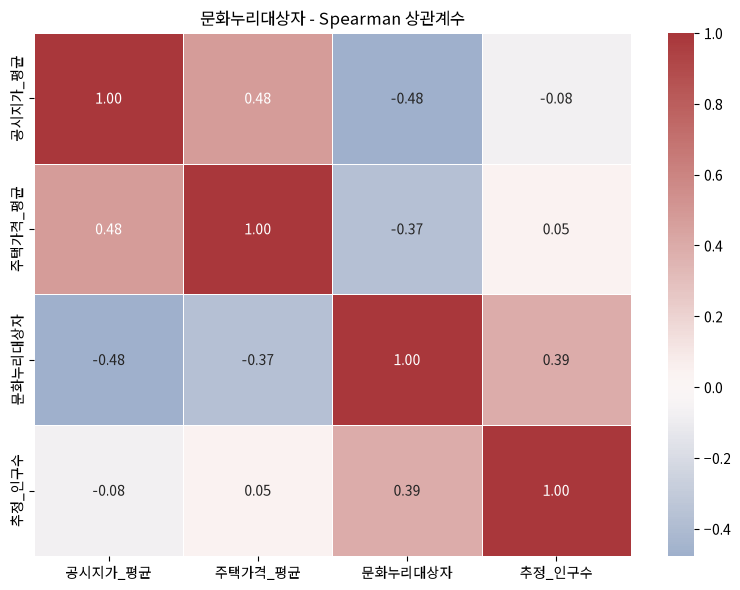

In [16]:
# 공시지가 - 문화누리 대상자 상관성 확인
    # 스피어만 상관 계수 기준, 문화누리대상자는 공시지가와 -0.48로 음의 관계를 보임
    # 주택 가격은 상대적으로 영향력 낮은 -0.37
hjd_land_corr = grid_mnc.groupby(["시군구", "행정동"]).agg(
    공시지가_평균=("공시지가", "mean"),
    주택가격_평균=("주택가격", "mean"),
    문화누리대상자=("문화누리대상자", "first"),
    추정_인구수=("추정_인구수", "sum")
)

plt.scatter(hjd_land_corr["공시지가_평균"],
            hjd_land_corr["문화누리대상자"],
            alpha = 0.3, 
            color = 'salmon')
plt.title("공시지가-문화누리대상자 산점도(행정동별)", fontsize=12)
plt.tight_layout()
plt.savefig(IMAGE_PATH / "공시지가_문화누리대상자_산점도.png", 
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi = 240)
plt.show()


pearson_corr = (hjd_land_corr.corr(method = 'pearson'))
spearman_corr = hjd_land_corr.corr(method = 'spearman')

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5
)

plt.title("문화누리대상자 - Spearman 상관계수")
plt.tight_layout()
plt.savefig(IMAGE_PATH / "공시지가_문화누리대상자_스피어만상관계수.png", 
            pad_inches = 0.1,
            bbox_inches = 'tight',
            dpi = 240)
plt.show()

## 가중치 생성
#### 문화누리 대상자 추정식
$$
\hat{T}_i
=
T_d
\times
\frac{
P_i\left(1+\frac{L_i}{c}\right)^{-\beta}
}{
\sum_{j\in d}
P_j\left(1+\frac{L_j}{c}\right)^{-\beta}
}
$$

- $\hat{T}_i$ = 100m 격자 $i$의 문화누리 대상자 추정 수
- $T_d$ = 격자 $i$가 속한 행정동 $d$의 문화누리 대상자 총수
- $P_i$ = 격자 $i$의 추정인구수
- $L_i$ = 격자 $i$의 공시지가
- $c$ = 서울시 전체 유효 격자 공시지가의 중앙값
- $\beta$ = 공시지가 반영 강도

# 행정동별 인구 비중

In [17]:
# 실제 행정동 인구수
hjd_pop = pd.read_csv(OUTPUT_PATH / "서울시_행정동별_인구수_2024.csv",
                      encoding = 'utf-8-sig')


grid_mnc_est = grid_mnc.copy()

grid_mnc_est = grid_mnc_est.merge(hjd_pop, 
                                  on = ["시군구", "행정동"],
                                  how = 'left')

# 인구비중
    # count    60528.000000
    # mean         0.063667
    # std          0.043625
    # min          0.000366
    # 25%          0.032616
    # 50%          0.058099
    # 75%          0.086471
    # max          0.311718
    # Name: 문화누리_비율, dtype: float64
grid_mnc_est["문화누리_비율"] = np.where(grid_mnc_est["행정동별_인구수"] > 0,
                                   grid_mnc_est["문화누리대상자"] / grid_mnc_est["행정동별_인구수"],
                                   0)

grid_mnc_est["문화누리_비율"].describe()


count    60528.000000
mean         0.063667
std          0.043625
min          0.000366
25%          0.032616
50%          0.058099
75%          0.086471
max          0.311718
Name: 문화누리_비율, dtype: float64

## 추정 가중치 생성 및 문화누리대상자 추정

In [18]:
#
beta_values = [0, 0.25, 0.5, 0.75, 1.0]
use_cols = [
    "GRID_CD", "시군구", "행정동", "추정_인구수",
    "공시지가", "문화누리대상자", "행정동별_인구수"
]

mnc_weight = grid_mnc_est[use_cols].copy()

# 행정동 별 문화누리 이용자 검증
print(f"행정동 별 문화누리 이용자 검증: {(mnc_weight.groupby(['시군구', '행정동'])["문화누리대상자"].nunique() > 1).sum()}")

# 기준값
c = mnc_weight.loc[(mnc_weight["공시지가"] > 0) & 
               (mnc_weight["추정_인구수"]>0), "공시지가"].median()
print(f"상대 공시지가 기준:{c}")

# 배분점수1
mnc_weight["행정동_문화누리비율"] = np.where(mnc_weight["행정동별_인구수"] > 0,
                                    mnc_weight["문화누리대상자"] / mnc_weight["행정동별_인구수"],
                                    0)
mnc_weight["문화누리추정수_1"] = (mnc_weight["추정_인구수"] * mnc_weight["행정동_문화누리비율"])

# 배분점수 2
mnc_weight["로그상대공시지가"] = np.log1p(mnc_weight["공시지가"] / c)

for beta in beta_values:
    result = mnc_weight.copy()
    
    result["배분점수"] = np.exp(-beta * result["로그상대공시지가"])
    result["격자별_배분점수"] = result["추정_인구수"] * result["배분점수"]
    
    result["행정동별_배분점수합"] = result.groupby(["시군구", "행정동"])["격자별_배분점수"].transform('sum')
    
    result["격자별_배분비율"] = result["격자별_배분점수"] / result["행정동별_배분점수합"]
    
    rate_test = result.groupby(["시군구", "행정동"], 
                               as_index=False) \
                                   ["격자별_배분비율"].sum()
    print(f"베타:{beta} 행정동별 배분비율 합 점검:{(rate_test["격자별_배분비율"] > 1+(1e-10)).sum()}")
    
    result["추정_문화누리"] = result["문화누리대상자"] * result["격자별_배분비율"]
    
    mnc_weight[f"문화누리추정수_{beta}"] = result["추정_문화누리"]


est_cols = mnc_weight.columns[
    mnc_weight.columns.str.startswith("문화누리추정수")] \
        .tolist()

행정동 별 문화누리 이용자 검증: 0
상대 공시지가 기준:3885211.165
베타:0 행정동별 배분비율 합 점검:0
베타:0.25 행정동별 배분비율 합 점검:0
베타:0.5 행정동별 배분비율 합 점검:0
베타:0.75 행정동별 배분비율 합 점검:0
베타:1.0 행정동별 배분비율 합 점검:0


In [19]:
# 문화누리추정수 점검

    # 결측치 확인
    # 문화누리추정수_1       0
    # 문화누리추정수_0       0
    # 문화누리추정수_0.25    0
    # 문화누리추정수_0.5     0
    # 문화누리추정수_0.75    0
    # 문화누리추정수_1.0     0


print("결측치 확인")
print(mnc_weight[est_cols].isna().sum())

display(mnc_weight[est_cols].describe())


결측치 확인
문화누리추정수_1       0
문화누리추정수_0       0
문화누리추정수_0.25    0
문화누리추정수_0.5     0
문화누리추정수_0.75    0
문화누리추정수_1.0     0
dtype: int64


,문화누리추정수_1,문화누리추정수_0,문화누리추정수_0.25,문화누리추정수_0.5,문화누리추정수_0.75,문화누리추정수_1.0
count,60528.000000,60528.000000,60528.000000,60528.000000,60528.000000,60528.000000
mean,9.650262,9.624455,9.624455,9.624455,9.624455,9.624455
std,17.849673,17.773139,17.744193,17.776405,17.868916,18.020742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,13.436244,13.374576,13.367629,13.312217,13.248937,13.182721
max,323.743306,332.525941,347.529809,375.754236,410.325471,447.094843


## 시군구 - 행정동 추정으로 역점검

    #              모형         MAE        RMSE      WAPE      MAPE
    # 0        역추정_1안  551.079469  796.591569  0.402987  1.458184
    # 1     역추정_2안_b0  551.263543  795.388541  0.403122  1.124180
    # 2  역추정_2안_b0.25  537.193037  779.701306  0.392833  1.088701
    # 3   역추정_2안_b0.5  526.049016  766.230001  0.384683  1.058021
    # 4  역추정_2안_b0.75  517.063951  755.055848  0.378113  1.031748
    # 5   역추정_2안_b1.0  510.013521  746.306455  0.372957  1.009781

    # 시군구 문화누리대상자 총량을 행정동 단위로 재배분하는 역검정 결과,
    # 공시지가를 반영하지 않은 1안 및 beta=0 모형보다
    # 공시지가 가중치를 반영한 2안의 오차가 전반적으로 낮게 나타남.
    # 공시지가 반영도를 높게 할 수록 오차가 갈수록 줄어들었으며
    # beta=1.0에서 MAE, RMSE, WAPE, MAPE가 모두 가장 낮아,
    # 현재 후보군 내에서는 공시지가를 강하게 반영한 배분 방식(beta = 1)이
    # 행정동별 문화누리대상자 분포를 가장 잘 재현하는 것으로 확인됨.


             모형         MAE        RMSE      WAPE      MAPE
0        역추정_1안  551.079469  796.591569  0.402987  1.458184
1     역추정_2안_b0  551.263543  795.388541  0.403122  1.124180
2  역추정_2안_b0.25  537.193037  779.701306  0.392833  1.088701
3   역추정_2안_b0.5  526.049016  766.230001  0.384683  1.058021
4  역추정_2안_b0.75  517.063951  755.055848  0.378113  1.031748
5   역추정_2안_b1.0  510.013521  746.306455  0.372957  1.009781


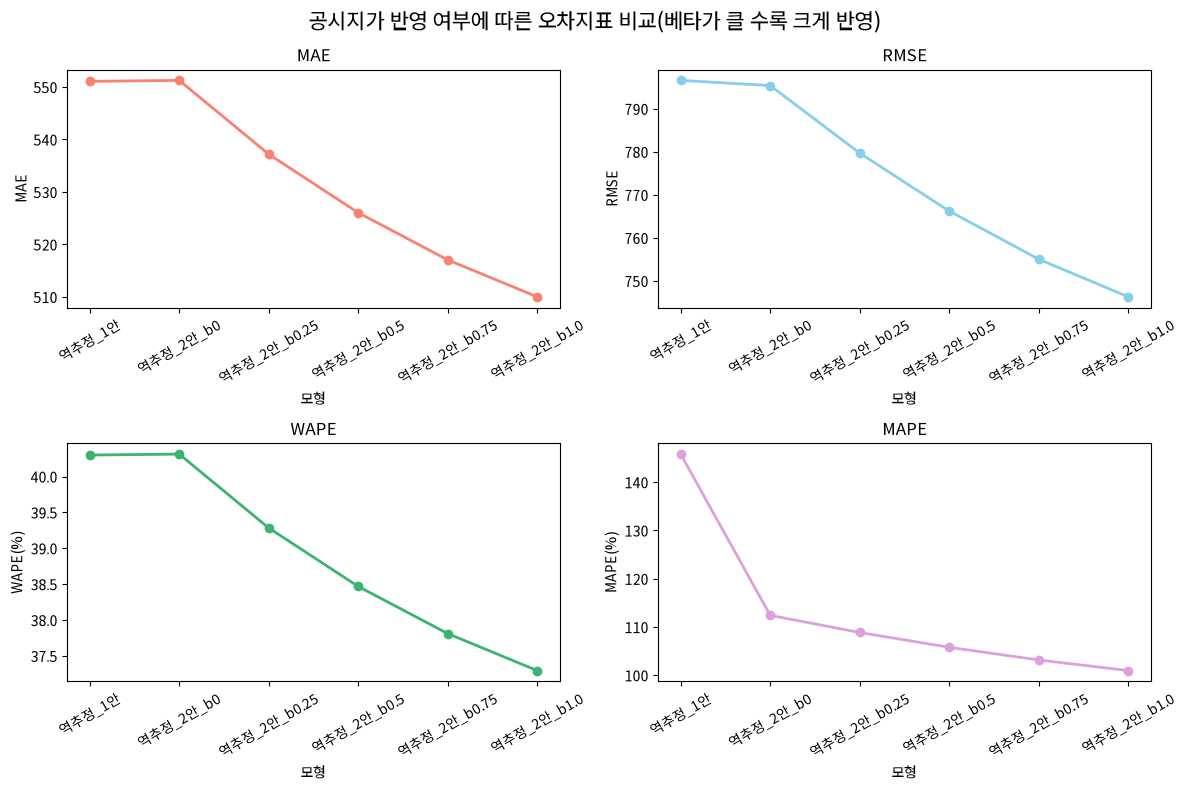

In [20]:
group_dong = ["시군구", "행정동"]

# 1. 행정동 실제값 테이블
dong_actual = (
    mnc_weight
    .groupby(group_dong, as_index=False)
    .agg(
        실제_문화누리대상자=("문화누리대상자", "first"),
        행정동별_인구수=("행정동별_인구수", "first")
    )
)

# 2. 시군구 총량
gu_total = (
    dong_actual
    .groupby("시군구", as_index=False)
    .agg(
        시군구_문화누리대상자=("실제_문화누리대상자", "sum"),
        시군구_인구수=("행정동별_인구수", "sum")
    )
)

# 3. 1안 역검정
# 시군구 문화누리비율 x 행정동 인구수
reverse_test = dong_actual.merge(
    gu_total,
    on="시군구",
    how="left",
    validate="many_to_one"
)

reverse_test["역추정_1안"] = np.where(
    reverse_test["시군구_인구수"] > 0,
    reverse_test["행정동별_인구수"]
    * reverse_test["시군구_문화누리대상자"]
    / reverse_test["시군구_인구수"],
    0
)

# 4. 2안 역검정
# 시군구 문화누리대상자 총량을 행정동별 배분점수 비율로 재배분
for beta in beta_values:
    beta_name = str(beta)
    
    score_col = f"역검정_격자배분점수_b{beta_name}"
    dong_score_col = f"행정동_배분점수_b{beta_name}"
    gu_score_col = f"시군구_배분점수_b{beta_name}"
    pred_col = f"역추정_2안_b{beta_name}"
    
    mnc_weight[score_col] = (
        mnc_weight["추정_인구수"]
        * np.exp(-beta * mnc_weight["로그상대공시지가"])
    )
    
    dong_score = (
        mnc_weight
        .groupby(group_dong, as_index=False)[score_col]
        .sum()
        .rename(columns={score_col: dong_score_col})
    )
    
    reverse_test = reverse_test.merge(
        dong_score,
        on=group_dong,
        how="left",
        validate="one_to_one"
    )
    
    reverse_test[gu_score_col] = (
        reverse_test
        .groupby("시군구")[dong_score_col]
        .transform("sum")
    )
    
    reverse_test[pred_col] = np.where(
        reverse_test[gu_score_col] > 0,
        reverse_test["시군구_문화누리대상자"]
        * reverse_test[dong_score_col]
        / reverse_test[gu_score_col],
        0
    )

# 5. 오차 계산
pred_cols = ["역추정_1안"] + [
    f"역추정_2안_b{str(beta)}"
    for beta in beta_values
]

for col in pred_cols:
    reverse_test[f"{col}_오차"] = (
        reverse_test["실제_문화누리대상자"] - reverse_test[col]
    )
    reverse_test[f"{col}_절대오차"] = reverse_test[f"{col}_오차"].abs()
    reverse_test[f"{col}_오차율"] = np.where(
        reverse_test["실제_문화누리대상자"] > 0,
        reverse_test[f"{col}_절대오차"] / reverse_test["실제_문화누리대상자"],
        0
    )

# 6. 전체 지표
metric_rows = []

for col in pred_cols:
    error = reverse_test[f"{col}_오차"]
    abs_error = reverse_test[f"{col}_절대오차"]
    
    metric_rows.append({
        "모형": col,
        "MAE": abs_error.mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "WAPE": abs_error.sum() / reverse_test["실제_문화누리대상자"].sum(),
        "MAPE": reverse_test[f"{col}_오차율"].mean()
    })

metric_df = pd.DataFrame(metric_rows)
print(metric_df)

# 역검정 오차지표 subplot 시각화

metric_plot = metric_df.copy()

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

metric_info = [
    ("MAE", "MAE"),
    ("RMSE", "RMSE"),
    ("WAPE", "WAPE"),
    ("MAPE", "MAPE")
]

colors = ["salmon", "skyblue", "mediumseagreen", "plum"]

for ax, (metric, title), color in zip(axs.ravel(), metric_info, colors):
    y = metric_plot[metric]
    
    if metric in ["WAPE", "MAPE"]:
        y = y * 100
        ylabel = f"{metric}(%)"
    else:
        ylabel = metric
    
    ax.plot(
        metric_plot["모형"],
        y,
        marker="o",
        linewidth=2,
        color=color
    )
    
    ax.set_title(title)
    ax.set_xlabel("모형")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("공시지가 반영 여부에 따른 오차지표 비교(베타가 클 수록 크게 반영)", fontsize=15)
plt.tight_layout()
plt.savefig(
    IMAGE_PATH / "문화누리대상자_역검정_오차비교.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=240
)
plt.show()

    #              모형         MAE        RMSE      WAPE      MAPE
    # 0        역추정_1안  551.079469  796.591569  0.402987  1.458184
    # 1     역추정_2안_b0  551.263543  795.388541  0.403122  1.124180
    # 2  역추정_2안_b0.25  537.193037  779.701306  0.392833  1.088701
    # 3   역추정_2안_b0.5  526.049016  766.230001  0.384683  1.058021
    # 4  역추정_2안_b0.75  517.063951  755.055848  0.378113  1.031748
    # 5   역추정_2안_b1.0  510.013521  746.306455  0.372957  1.009781

    # 시군구 문화누리대상자 총량을 행정동 단위로 재배분하는 역검정 결과,
    # 공시지가를 반영하지 않은 1안 및 beta=0 모형보다
    # 공시지가 가중치를 반영한 2안의 오차가 전반적으로 낮게 나타남.
    # 공시지가 반영도를 높게 할 수록 오차가 갈수록 줄어들었으며
    # beta=1.0에서 MAE, RMSE, WAPE, MAPE가 모두 가장 낮아,
    # 현재 후보군 내에서는 공시지가를 강하게 반영한 배분 방식(beta = 1)이
    # 행정동별 문화누리대상자 분포를 가장 잘 재현하는 것으로 확인됨.

## largest remainder method기반 인구 정수화
- 문화누리추정인구수 정수화 (소수점 내림) 후, 
- 행정동 별로 정수 보정으로 인한 인구 잔차를 행정동 별로 분배.
- 분배 기준은 소수점 내림차순.

In [ ]:
# 테이블 결합
grid_mnc_est_final = grid_mnc_est.merge(mnc_weight[["GRID_CD", "문화누리추정수_1.0"]], 
                                        on = "GRID_CD",
                                        how = 'left')

grid_mnc_est_final.rename(columns = {"문화누리추정수_1.0": '문화누리대상자_추정_인구수'}, 
                          inplace = True, 
                          errors = 'ignore')


grid_mnc_est_final["문화누리대상자_추정_인구수_내림"] = np.floor(grid_mnc_est_final["문화누리대상자_추정_인구수"]).astype(int)
grid_mnc_est_final["문화누리대상자_소수점"] = grid_mnc_est_final["문화누리대상자_추정_인구수"] - grid_mnc_est_final["문화누리대상자_추정_인구수_내림"]

grid_mnc_est_final["행정동별_내림합"] = grid_mnc_est_final.groupby(["시군구", "행정동"])["문화누리대상자_추정_인구수_내림"].transform("sum")

grid_mnc_est_final["행정동별_잔여배분인원"] = (
    grid_mnc_est_final["문화누리대상자"]
    - grid_mnc_est_final["행정동별_내림합"]
).astype(int)

grid_mnc_est_final = grid_mnc_est_final.sort_values(
    ["시군구", "행정동", "문화누리대상자_소수점"],
    ascending=[True, True, False]
).copy()

grid_mnc_est_final["행정동내_소수점순위"] = (
    grid_mnc_est_final
    .groupby(["시군구", "행정동"])
    .cumcount()
    + 1
)

grid_mnc_est_final["문화누리대상자_추정_인구수"] = (
    grid_mnc_est_final["문화누리대상자_추정_인구수_내림"]
    + (
        grid_mnc_est_final["행정동내_소수점순위"]
        <= grid_mnc_est_final["행정동별_잔여배분인원"]
    ).astype(int)
)

grid_mnc_est_final = grid_mnc_est_final.sort_index().copy()


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,추정_인구수,...,공시지가,주택가격,행정동별_인구수,문화누리_비율,문화누리대상자_추정_인구수,문화누리대상자_추정_인구수_내림,문화누리대상자_소수점,행정동별_내림합,행정동별_잔여배분인원,행정동내_소수점순위
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,0,...,21500.000000,NaN,21042,0.053512,0,0,0.0,1068,58,102
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,0,...,21949.995000,NaN,21042,0.053512,0,0,0.0,1068,58,103
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,0,...,30233.336667,NaN,21042,0.053512,0,0,0.0,1068,58,104
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,0,...,77118.103333,NaN,16863,0.069798,0,0,0.0,1099,78,175
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,0,...,21699.990000,NaN,21042,0.053512,0,0,0.0,1068,58,105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60523,다사577668,11100640,도봉구,도봉1동,957750.0,1966850.0,0.0,0.0,0.0,0,...,374954.712128,NaN,19603,0.138550,0,0,0.0,2663,53,838
60524,다사583668,11100640,도봉구,도봉1동,958350.0,1966850.0,0.0,0.0,0.0,0,...,6730.000000,NaN,19603,0.138550,0,0,0.0,2663,53,839
60525,다사573669,11100640,도봉구,도봉1동,957350.0,1966950.0,0.0,0.0,0.0,0,...,374954.712128,NaN,19603,0.138550,0,0,0.0,2663,53,840
60526,다사574669,11100640,도봉구,도봉1동,957450.0,1966950.0,0.0,0.0,0.0,0,...,374954.712128,NaN,19603,0.138550,0,0,0.0,2663,53,841


## 격자별 문화누리대상자 추정인구 확정

,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,원본_인구수,주거면적,주택수,공시지가,추정_인구수,문화누리대상자_추정_인구수,GRID_CD_500,geometry
0,다사603367,11220670,서초구,양재2동,960350.0,1936750.0,0.0,0.0,0.0,21500.000000,0,0,다사60a36b,"POLYGON ((960300 1936700, 960300 1936800, 9604..."
1,다사604367,11220670,서초구,양재2동,960450.0,1936750.0,0.0,0.0,0.0,21949.995000,0,0,다사60a36b,"POLYGON ((960400 1936700, 960400 1936800, 9605..."
2,다사605367,11220670,서초구,양재2동,960550.0,1936750.0,0.0,0.0,0.0,30233.336667,0,0,다사60b36b,"POLYGON ((960500 1936700, 960500 1936800, 9606..."
3,다사615367,11220680,서초구,내곡동,961550.0,1936750.0,0.0,0.0,0.0,77118.103333,0,0,다사61b36b,"POLYGON ((961500 1936700, 961500 1936800, 9616..."
4,다사602368,11220670,서초구,양재2동,960250.0,1936850.0,0.0,0.0,0.0,21699.990000,0,0,다사60a36b,"POLYGON ((960200 1936800, 960200 1936900, 9603..."
5,다사603368,11220670,서초구,양재2동,960350.0,1936850.0,0.0,0.0,0.0,21949.995000,0,0,다사60a36b,"POLYGON ((960300 1936800, 960300 1936900, 9604..."
6,다사604368,11220670,서초구,양재2동,960450.0,1936850.0,0.0,0.0,0.0,22900.000000,0,0,다사60a36b,"POLYGON ((960400 1936800, 960400 1936900, 9605..."
7,다사605368,11220670,서초구,양재2동,960550.0,1936850.0,0.0,0.0,0.0,21700.000000,0,0,다사60b36b,"POLYGON ((960500 1936800, 960500 1936900, 9606..."
8,다사606368,11220670,서초구,양재2동,960650.0,1936850.0,0.0,0.0,0.0,21500.000000,0,0,다사60b36b,"POLYGON ((960600 1936800, 960600 1936900, 9607..."
9,다사607368,11220670,서초구,양재2동,960750.0,1936850.0,0.0,0.0,0.0,30233.336667,0,0,다사60b36b,"POLYGON ((960700 1936800, 960700 1936900, 9608..."


최종 테이블 결측치 확인
GRID_CD           0
행정동코드             0
시군구               0
행정동               0
중심점_x             0
중심점_y             0
원본_인구수            0
주거면적              0
주택수               0
공시지가              0
추정_인구수            0
문화누리대상자_추정_인구수    0
GRID_CD_500       0
geometry          0
dtype: int64
최종 테이블 격자 중복값 확인: 0
최종 테이블 구조 확인: (60528, 14)
최종 테이블 격자 타입 확인: <class 'geopandas.geodataframe.GeoDataFrame'>


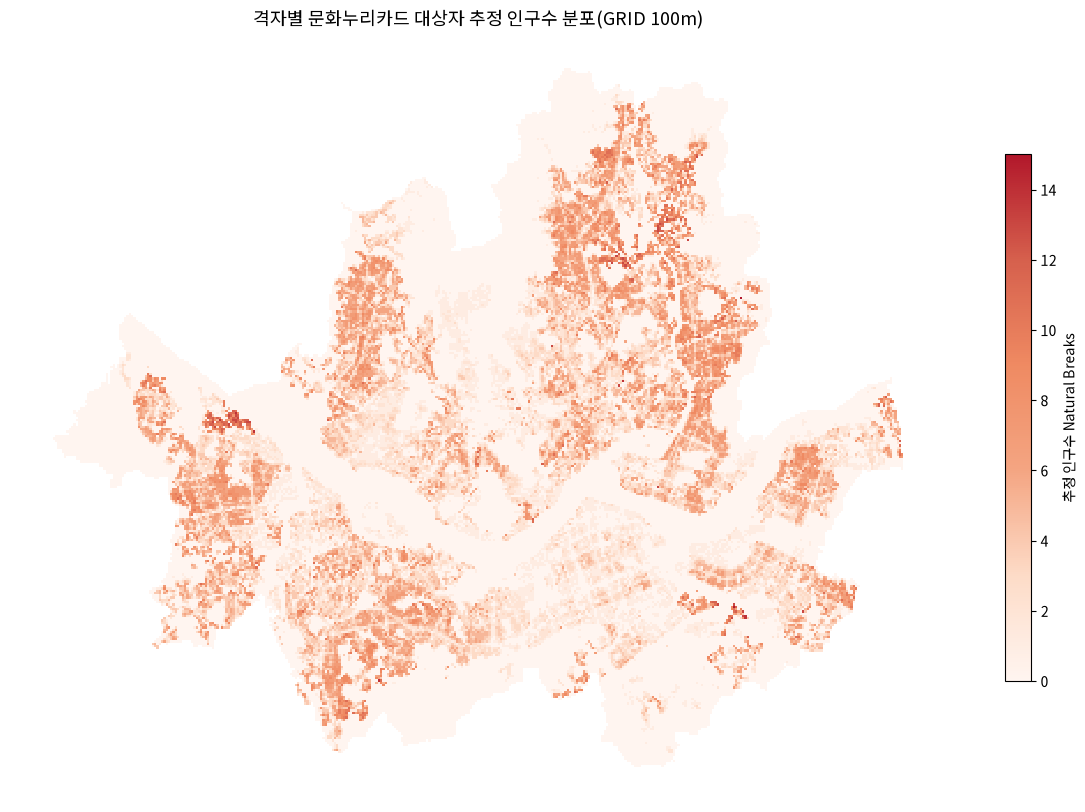

In [39]:
# 필요 칼럼 선택
fin_columns = ['GRID_CD', '행정동코드', '시군구', '행정동', '중심점_x', '중심점_y', '원본_인구수', '주거면적',
       '주택수','공시지가', '추정_인구수','문화누리대상자_추정_인구수',  'GRID_CD_500', 'geometry']

grid_mnc_est_final = grid_mnc_est_final[fin_columns]

# 점검
display(grid_mnc_est_final.head(10))
print("최종 테이블 결측치 확인")
print(grid_mnc_est_final.isna().sum())
print(f"최종 테이블 격자 중복값 확인: {grid_mnc_est_final["GRID_CD"].duplicated().sum()}")
print(f"최종 테이블 구조 확인: {grid_mnc_est_final.shape}")
print(f"최종 테이블 격자 타입 확인: {type(grid_mnc_est_final)}")

# 시각화
plot_col = "문화누리대상자_추정_인구수"

plot_grid = grid_mnc_est_final.copy()

plot_grid["문화누리대상자_추정_인구수_nb"] = 0

positive_idx = plot_grid[plot_col] > 0

plot_grid.loc[positive_idx, "문화누리대상자_추정_인구수_nb"] = (
    mc.NaturalBreaks(
        plot_grid.loc[positive_idx, plot_col],
        k=15
    ).yb + 1
)

fig, ax = plt.subplots(figsize=(12, 12))

plot_grid.plot(
    ax=ax,
    column="문화누리대상자_추정_인구수_nb",
    cmap=salmon_cmap,
    legend_kwds={
        "shrink": 0.45,
        "label": "추정 인구수 Natural Breaks"
    },
    edgecolor=None,
    legend=True
)

ax.set_title("격자별 문화누리카드 대상자 추정 인구수 분포(GRID 100m)", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    IMAGE_PATH / "격자별_문화누리대상자추정인구수_분포지도.png",
    pad_inches=0.1,
    bbox_inches="tight",
    dpi=240
)
plt.show()

## 최종 테이블 생성

In [41]:
grid_mnc_est_final.to_file(OUTPUT_PATH / "서울시_100m_문화누리추정인구수.gpkg",
                           driver = "GPKG")